# Stage Transition Model

**Goal:** At each stage transition, predict:
- `P(advances to next stage | current stage)` 
- `P(lost | current stage) = 1 - P(advances)`

Dataset: `stage_transitions_model.csv` — one row per actual stage transition from stages 1-7, labeled `advanced=1` (moved forward) or `advanced=0` (moved to closed-lost).

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from catboost import CatBoostClassifier

In [134]:
df = pd.read_csv("res-tod.csv")
print(f"Rows: {len(df)}, Unique opps: {df['opportunity_id'].nunique()}")
display(df.head())

Rows: 3969, Unique opps: 3091


,opportunity_id,display_id,snapshot_version,snapshot_date,current_stage,next_stage,opportunity_type,segment,days_in_current_stage,days_in_sales_cycle,...,sig_sentiment_mean,sig_sentiment_last,sig_sentiment_first,sig_sentiment_min,sig_sentiment_max,sig_pain_any,sig_pain_rate,sig_pricing_any,sig_pricing_rate,sig_confidence_mean
0,don:core:dvrv-us-1:devo/0:opportunity/10000,OPP-10000,213,2026-07-14 18:39:24.051,3-evaluate,9-closed_lost,New,Enterprise,76.0,134.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,don:core:dvrv-us-1:devo/0:opportunity/10002,OPP-10002,103,2026-05-26 03:49:58.517,1-profile,9-closed_lost,New,Mid-Market,84.0,84.0,...,0.350000,0.35,0.35,0.35,0.35,0.0,0.0,0.0,0.0,1.00
2,don:core:dvrv-us-1:devo/0:opportunity/10006,OPP-10006,141,2026-05-27 13:55:54.875,3-evaluate,5-validate,New,SMB,86.0,86.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,don:core:dvrv-us-1:devo/0:opportunity/10011,OPP-10011,79,2026-05-14 00:21:52.017,1-profile,9-closed_lost,New,Enterprise,71.0,71.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,don:core:dvrv-us-1:devo/0:opportunity/10014,OPP-10014,238,2026-06-17 04:58:42.848,3-evaluate,5-validate,New,Enterprise,54.0,105.0,...,0.606667,0.62,0.62,0.58,0.62,1.0,1.0,1.0,1.0,0.86


In [135]:
print("\nLabel distribution:")
print(df["advanced"].value_counts())
print(f"\nAdvance rate: {df['advanced'].mean():.3f}")


Label distribution:
advanced
0    2492
1    1476
4       1
Name: count, dtype: int64

Advance rate: 0.373


In [136]:
print("\nBy current stage:")
display(
    df.groupby("current_stage")["advanced"]
      .agg(["count", "sum", "mean"])
      .rename(columns={"count": "transitions", "sum": "advanced", "mean": "advance_rate"})
      .sort_index()
)


By current stage:


,transitions,advanced,advance_rate
current_stage,,,
1-profile,2626,893,0.340061
2-qualify,629,209,0.332273
3-evaluate,370,135,0.364865
4-go_no_go,93,57,0.612903
5-validate,101,63,0.623762
6-negotiate,83,55,0.662651
7-submit_for_close,66,64,0.969697
9-closed_lost,1,4,4.000000


In [137]:
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing values:
sig_confidence_mean      2391
sig_count                2391
sig_pricing_rate         2391
sig_pricing_any          2391
sig_pain_rate            2391
sig_pain_any             2391
sig_sentiment_max        2391
sig_sentiment_min        2391
sig_sentiment_first      2391
sig_sentiment_last       2391
sig_sentiment_mean       2391
days_in_current_stage     462
days_in_sales_cycle       462
segment                   267
opportunity_id              1
meetings_conducted          1
display_id                  0
contract_length             0
has_champion                0
stall_ratio                 0
opportunity_type            0
next_stage                  0
current_stage               0
snapshot_date               0
snapshot_version            0
advanced                    0
dtype: int64


## Feature Setup

In [138]:
# Clean: drop rows with NaN opportunity_id or invalid advanced values
df = df[df["opportunity_id"].notna()].reset_index(drop=True)
df = df[df["advanced"].isin([0, 1])].reset_index(drop=True)

# Drop 40% of rows missing signal data
signal_missing = df["sig_count"].isna()
drop_frac = 0.4
drop_idx = df[signal_missing].sample(frac=drop_frac, random_state=42).index
df = df.drop(drop_idx).reset_index(drop=True)
print(f"Dropped {len(drop_idx)} rows (40% of signal-missing). Remaining: {len(df)} rows, {df['opportunity_id'].nunique()} opps")

feature_columns = [
    "current_stage",
    "opportunity_type",
    "segment",
    "stall_ratio",
    "has_champion",
    "contract_length",
    "days_in_current_stage",
    "days_in_sales_cycle",
    "meetings_conducted",
    # Signal features from meeting_signals
    "sig_count",
    "sig_sentiment_mean",
    "sig_sentiment_min",
    "sig_sentiment_max",
    "sig_pain_any",
    "sig_pain_rate",
    "sig_pricing_any",
    "sig_pricing_rate",
    "sig_confidence_mean",
]

categorical_features = ["current_stage", "opportunity_type", "segment"]
numeric_features = [
    "stall_ratio",
    "has_champion",
    "contract_length",
    "days_in_current_stage", "days_in_sales_cycle",
    "meetings_conducted",
    "sig_count",
    "sig_sentiment_mean",
    "sig_sentiment_min",
    "sig_sentiment_max",
    "sig_pain_any",
    "sig_pain_rate",
    "sig_pricing_any",
    "sig_pricing_rate",
    "sig_confidence_mean",
]

X = df[feature_columns].copy()
y = df["advanced"].astype(int)
groups = df["opportunity_id"]

# CatBoost prep
for col in categorical_features:
    X[col] = X[col].fillna("UNKNOWN").astype(str)

for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print(f"X: {X.shape}, y: {y.shape}")
print(f"Groups: {groups.nunique()} unique opportunities")

Dropped 956 rows (40% of signal-missing). Remaining: 3012 rows, 2353 opps
X: (3012, 18), y: (3012,)
Groups: 2353 unique opportunities


## Cross-Validation (GroupKFold)

In [139]:
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X, y, groups))

for fold_num, (train_idx, test_idx) in enumerate(folds, 1):
    train_opps = set(groups.iloc[train_idx])
    test_opps = set(groups.iloc[test_idx])
    overlap = train_opps & test_opps
    print(f"Fold {fold_num}: train={len(train_opps)} opps, test={len(test_opps)} opps, overlap={len(overlap)}")

Fold 1: train=1882 opps, test=471 opps, overlap=0
Fold 2: train=1882 opps, test=471 opps, overlap=0
Fold 3: train=1883 opps, test=470 opps, overlap=0
Fold 4: train=1883 opps, test=470 opps, overlap=0
Fold 5: train=1882 opps, test=471 opps, overlap=0


## CatBoost Training

In [140]:
results = []
all_oof = []

for fold_num, (train_idx, test_idx) in enumerate(folds, 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = CatBoostClassifier(
        iterations=800,
        depth=6,
        learning_rate=0.02,
        loss_function="Logloss",
        eval_metric="PRAUC",
        auto_class_weights="Balanced",
        l2_leaf_reg=7,
        min_data_in_leaf=10,
        random_seed=42,
        verbose=False,
    )

    model.fit(X_train, y_train, cat_features=categorical_features)

    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "fold": fold_num,
        "PR_AUC": average_precision_score(y_test, probs),
        "ROC_AUC": roc_auc_score(y_test, probs),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "Brier": brier_score_loss(y_test, probs),
    }
    results.append(metrics)

    all_oof.append(pd.DataFrame({
        "opportunity_id": groups.iloc[test_idx].values,
        "current_stage": df["current_stage"].iloc[test_idx].values,
        "actual": y_test.values,
        "p_advance": probs,
        "p_lost": 1 - probs,
        "fold": fold_num,
    }))

results_df = pd.DataFrame(results)
display(results_df)

,fold,PR_AUC,ROC_AUC,Precision,Recall,F1,Brier
0,1,0.874596,0.906031,0.775665,0.819277,0.796875,0.123002
1,2,0.869842,0.890800,0.752988,0.774590,0.763636,0.131567
2,3,0.862679,0.895469,0.770492,0.773663,0.772074,0.129499
3,4,0.854324,0.891105,0.720472,0.785408,0.751540,0.132206
4,5,0.851645,0.888278,0.763713,0.763713,0.763713,0.132118


In [141]:
print("\nMean ± Std:")
display(results_df[["PR_AUC","ROC_AUC","Precision","Recall","F1","Brier"]].agg(["mean","std"]))


Mean ± Std:


,PR_AUC,ROC_AUC,Precision,Recall,F1,Brier
mean,0.862617,0.894336,0.756666,0.783330,0.769568,0.129679
std,0.009809,0.007030,0.021939,0.021513,0.016929,0.003890


## Feature Importance

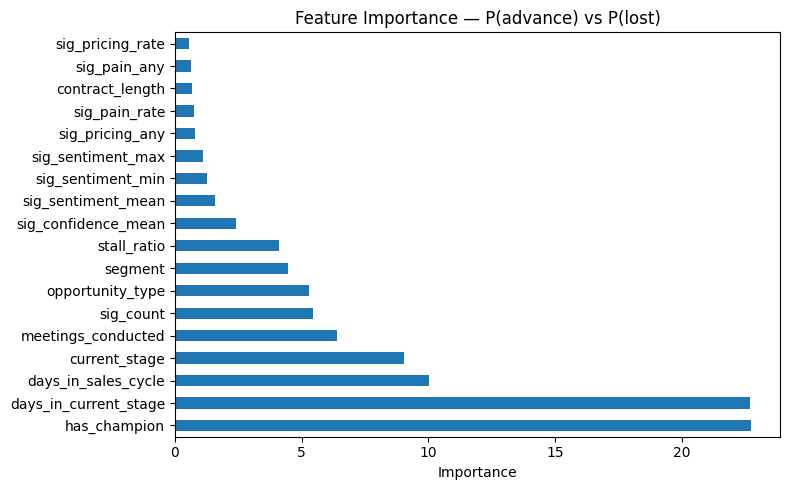

has_champion             22.732577
days_in_current_stage    22.669967
days_in_sales_cycle      10.034636
current_stage             9.053738
meetings_conducted        6.401240
sig_count                 5.445296
opportunity_type          5.294979
segment                   4.462411
stall_ratio               4.094546
sig_confidence_mean       2.415709
sig_sentiment_mean        1.596796
sig_sentiment_min         1.263392
sig_sentiment_max         1.118322
sig_pricing_any           0.783738
sig_pain_rate             0.748812
contract_length           0.689856
sig_pain_any              0.621484
sig_pricing_rate          0.572503
dtype: float64


In [142]:
# Retrain on full data for feature importance
final_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False,
)
final_model.fit(X, y, cat_features=categorical_features)

importance = pd.Series(
    final_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Feature Importance — P(advance) vs P(lost)")
plt.tight_layout()
plt.show()

print(importance)

## Calibration

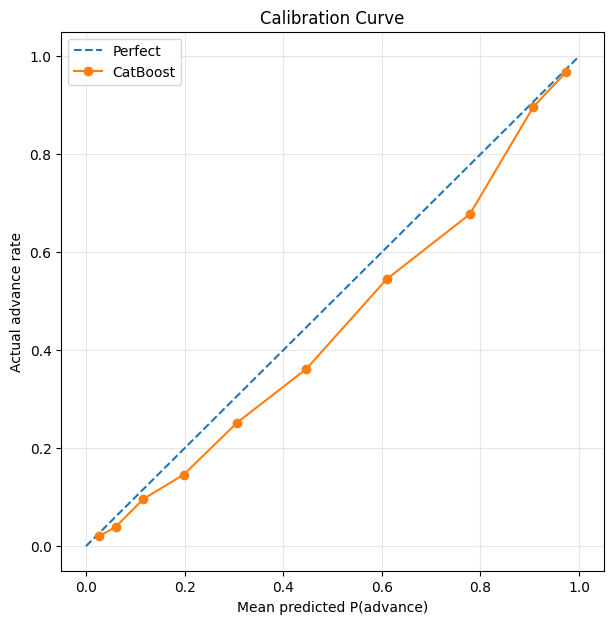

Overall Brier: 0.1297


In [143]:
oof_df = pd.concat(all_oof, ignore_index=True)

# Calibration curve
prob_true, prob_pred = calibration_curve(
    oof_df["actual"], oof_df["p_advance"], n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "--", label="Perfect")
plt.plot(prob_pred, prob_true, "o-", label="CatBoost")
plt.xlabel("Mean predicted P(advance)")
plt.ylabel("Actual advance rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Overall Brier: {brier_score_loss(oof_df['actual'], oof_df['p_advance']):.4f}")

## Per-Stage Predictions

In [127]:
stage_perf = (
    oof_df.groupby("current_stage")
    .agg(
        n=("actual", "size"),
        actual_advance_rate=("actual", "mean"),
        mean_p_advance=("p_advance", "mean"),
        mean_p_lost=("p_lost", "mean"),
    )
    .sort_index()
)
display(stage_perf)

,n,actual_advance_rate,mean_p_advance,mean_p_lost
current_stage,,,,
1-profile,644,0.473602,0.486225,0.513775
2-qualify,349,0.355301,0.381424,0.618576
3-evaluate,227,0.414097,0.406825,0.593175
4-go_no_go,67,0.626866,0.666010,0.333990
5-validate,71,0.676056,0.640382,0.359618
6-negotiate,51,0.666667,0.637682,0.362318
7-submit_for_close,37,1.000000,0.875918,0.124082


In [24]:
# Output: two-column prediction table
print("\nSample predictions (P(advance) and P(lost) per transition):")
display(oof_df[["opportunity_id","current_stage","actual","p_advance","p_lost"]].head(15))


Sample predictions (P(advance) and P(lost) per transition):


,opportunity_id,current_stage,actual,p_advance,p_lost
0,don:core:dvrv-us-1:devo/0:opportunity/10044,1-profile,0,0.022237,0.977763
1,don:core:dvrv-us-1:devo/0:opportunity/10089,1-profile,0,0.010853,0.989147
2,don:core:dvrv-us-1:devo/0:opportunity/10169,1-profile,0,0.024575,0.975425
3,don:core:dvrv-us-1:devo/0:opportunity/10212,1-profile,0,0.009879,0.990121
4,don:core:dvrv-us-1:devo/0:opportunity/10233,2-qualify,0,0.089204,0.910796
5,don:core:dvrv-us-1:devo/0:opportunity/10260,3-evaluate,0,0.215729,0.784271
6,don:core:dvrv-us-1:devo/0:opportunity/10304,3-evaluate,1,0.565411,0.434589
7,don:core:dvrv-us-1:devo/0:opportunity/10304,5-validate,1,0.591015,0.408985
8,don:core:dvrv-us-1:devo/0:opportunity/10304,6-negotiate,1,0.874956,0.125044
9,don:core:dvrv-us-1:devo/0:opportunity/10304,7-submit_for_close,1,0.971040,0.028960


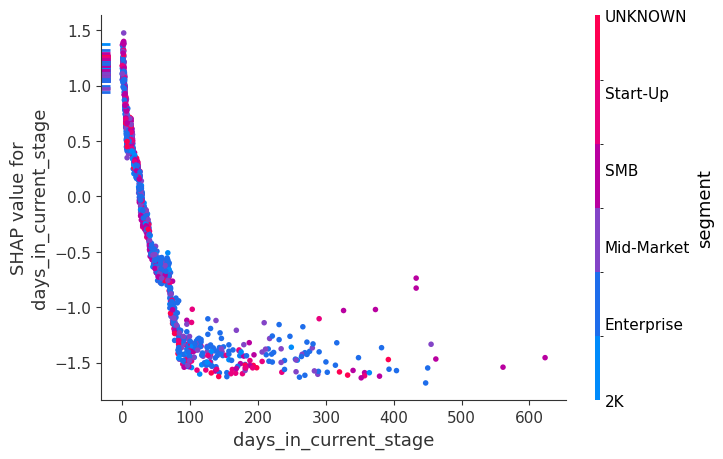

In [ ]:
import shap
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# Interaction between segment and days_in_current_stage
shap.dependence_plot("days_in_current_stage", shap_values, X, interaction_index="segment")

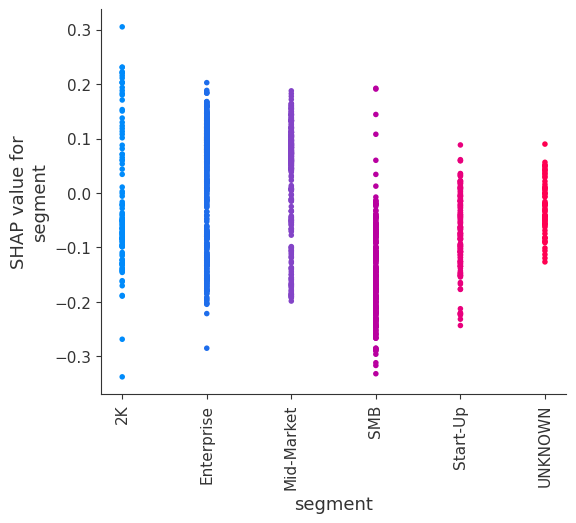

In [87]:
# Interaction between segment and days_in_current_stage
shap.dependence_plot("segment", shap_values, X, interaction_index="segment")